In [1]:
# imports and global settings, same setup used in class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

# helper functions (same ones from the class notebooks)
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

def pct_formatter(x, pos):
    return f"{x:.0f}%"

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def annotate_hbar(ax, fmt="{:,.1f}"):
    for p in ax.patches:
        w = p.get_width()
        ax.text(w, p.get_y() + p.get_height() / 2,
                " " + fmt.format(w),
                va="center", ha="left", fontsize=9)

# color palette used across the notebook
COL_BLUE = "#4C78A8"
COL_ORANGE = "#F58518"
COL_RED = "#E45756"
COL_TEAL = "#72B7B2"
COL_LIGHT = "#A0CBE8"

In [2]:
# load the raw dataset
df_raw = pd.read_csv("symbol_info_3-25.csv")
df_raw.shape

(1000, 38)

In [3]:
# cleaning step, same logic used in class
# keep only active, real companies (no ETFs, no funds) with positive market cap and revenue
df = df_raw.copy()
df = df[(df["is_etf"] == 0) &
        (df["is_fund"] == 0) &
        (df["is_actively_trading"] == 1) &
        (df["market_cap"] > 0) &
        (df["total_revenue"] > 0)].copy()

# derived columns in billions for readability on charts
df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# percentages, easier to read on axes than 0-1 ratios
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100

# infinite values can come out of ratios with zero denominators, replace them
df = df.replace([np.inf, -np.inf], np.nan)

df.shape

(993, 47)

In [4]:
# filter to my assigned sector
SECTOR = "Utilities"
df_sector = df[df["sector"] == SECTOR].copy()

print("companies in sector:", len(df_sector))
print("industries:", df_sector["industry"].nunique())
df_sector["industry"].value_counts()

companies in sector: 42
industries: 6


industry
Utilities - Regulated Electric             28
Utilities - Renewable                       3
Utilities - Diversified                     3
Utilities - Independent Power Producers     3
Utilities - Regulated Gas                   3
Utilities - Regulated Water                 2
Name: count, dtype: int64

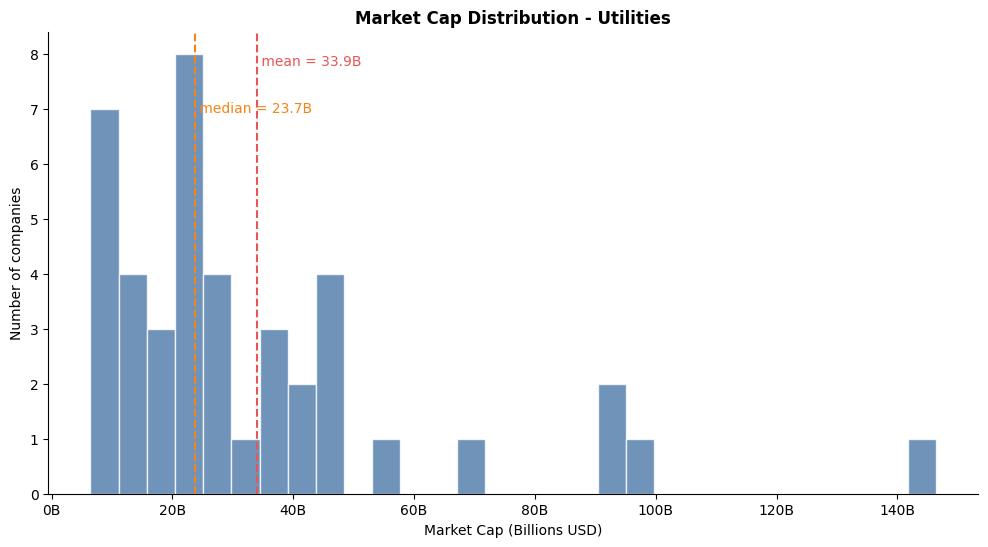

In [5]:
# Step 1, distribution of market cap inside the Utilities sector
# I use market_cap_b (billions) so the x axis is readable
mc = df_sector["market_cap_b"]

mean_val = mc.mean()
median_val = mc.median()

fig, ax = plt.subplots()
ax.hist(mc, bins=30, color=COL_BLUE, alpha=0.8, edgecolor="white")

# vertical lines for mean and median, annotated with their value
ax.axvline(mean_val, color=COL_RED, linestyle="--", linewidth=1.5)
ax.axvline(median_val, color=COL_ORANGE, linestyle="--", linewidth=1.5)

# place the labels near the top of the plot so they do not overlap the bars
ymax = ax.get_ylim()[1]
ax.text(mean_val, ymax * 0.95, f" mean = {mean_val:,.1f}B",
        color=COL_RED, va="top", ha="left", fontsize=10)
ax.text(median_val, ymax * 0.85, f" median = {median_val:,.1f}B",
        color=COL_ORANGE, va="top", ha="left", fontsize=10)

ax.set_title(f"Market Cap Distribution - {SECTOR}")
ax.set_xlabel("Market Cap (Billions USD)")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax)
plt.show()

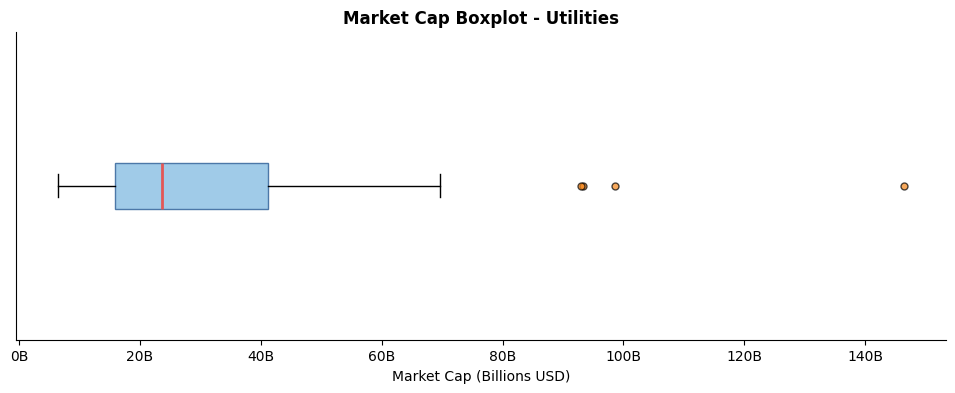

count     42.000000
mean      33.938689
std       29.008526
min        6.439596
25%       15.803523
50%       23.705724
75%       41.215223
max      146.357273
Name: market_cap_b, dtype: float64

In [6]:
# Step 2, boxplot of market cap to spot outliers
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(df_sector["market_cap_b"], vert=False,
           patch_artist=True,
           boxprops=dict(facecolor=COL_LIGHT, edgecolor=COL_BLUE),
           medianprops=dict(color=COL_RED, linewidth=2),
           flierprops=dict(marker="o", markerfacecolor=COL_ORANGE,
                           markersize=5, alpha=0.7))
ax.set_title(f"Market Cap Boxplot - {SECTOR}")
ax.set_xlabel("Market Cap (Billions USD)")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_yticks([])
clean_spines(ax)
plt.show()

# quick numeric look at the tail before deciding on outlier removal
df_sector["market_cap_b"].describe()

95th percentile cap: 93.35B
rows above the cap: 3


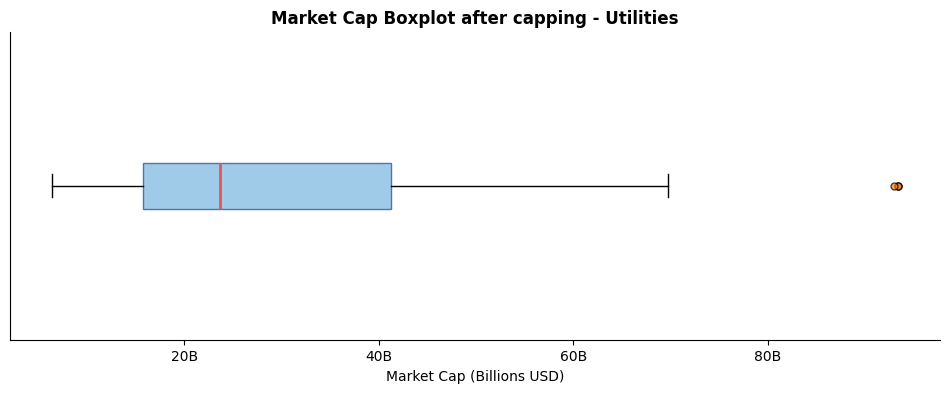

count    42.000000
mean     32.548972
std      24.518055
min       6.439596
25%      15.803523
50%      23.705724
75%      41.215223
max      93.345135
Name: market_cap_b, dtype: float64

In [7]:
# Step 2 cleanup, the boxplot above showed a long right tail (max 146B vs median 24B)
# I do not drop those rows because they are real companies, not data errors
# I cap market_cap_b at the 95th percentile so the tail does not distort later charts
# I keep all 42 rows, only the extreme values get clipped

cap_value = df_sector["market_cap_b"].quantile(0.95)
print(f"95th percentile cap: {cap_value:,.2f}B")
print(f"rows above the cap: {(df_sector['market_cap_b'] > cap_value).sum()}")

df_sector["market_cap_b"] = df_sector["market_cap_b"].clip(upper=cap_value)

# quick before/after view to confirm the tail is now under control
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(df_sector["market_cap_b"], vert=False,
           patch_artist=True,
           boxprops=dict(facecolor=COL_LIGHT, edgecolor=COL_BLUE),
           medianprops=dict(color=COL_RED, linewidth=2),
           flierprops=dict(marker="o", markerfacecolor=COL_ORANGE,
                           markersize=5, alpha=0.7))
ax.set_title(f"Market Cap Boxplot after capping - {SECTOR}")
ax.set_xlabel("Market Cap (Billions USD)")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.set_yticks([])
clean_spines(ax)
plt.show()

df_sector["market_cap_b"].describe()

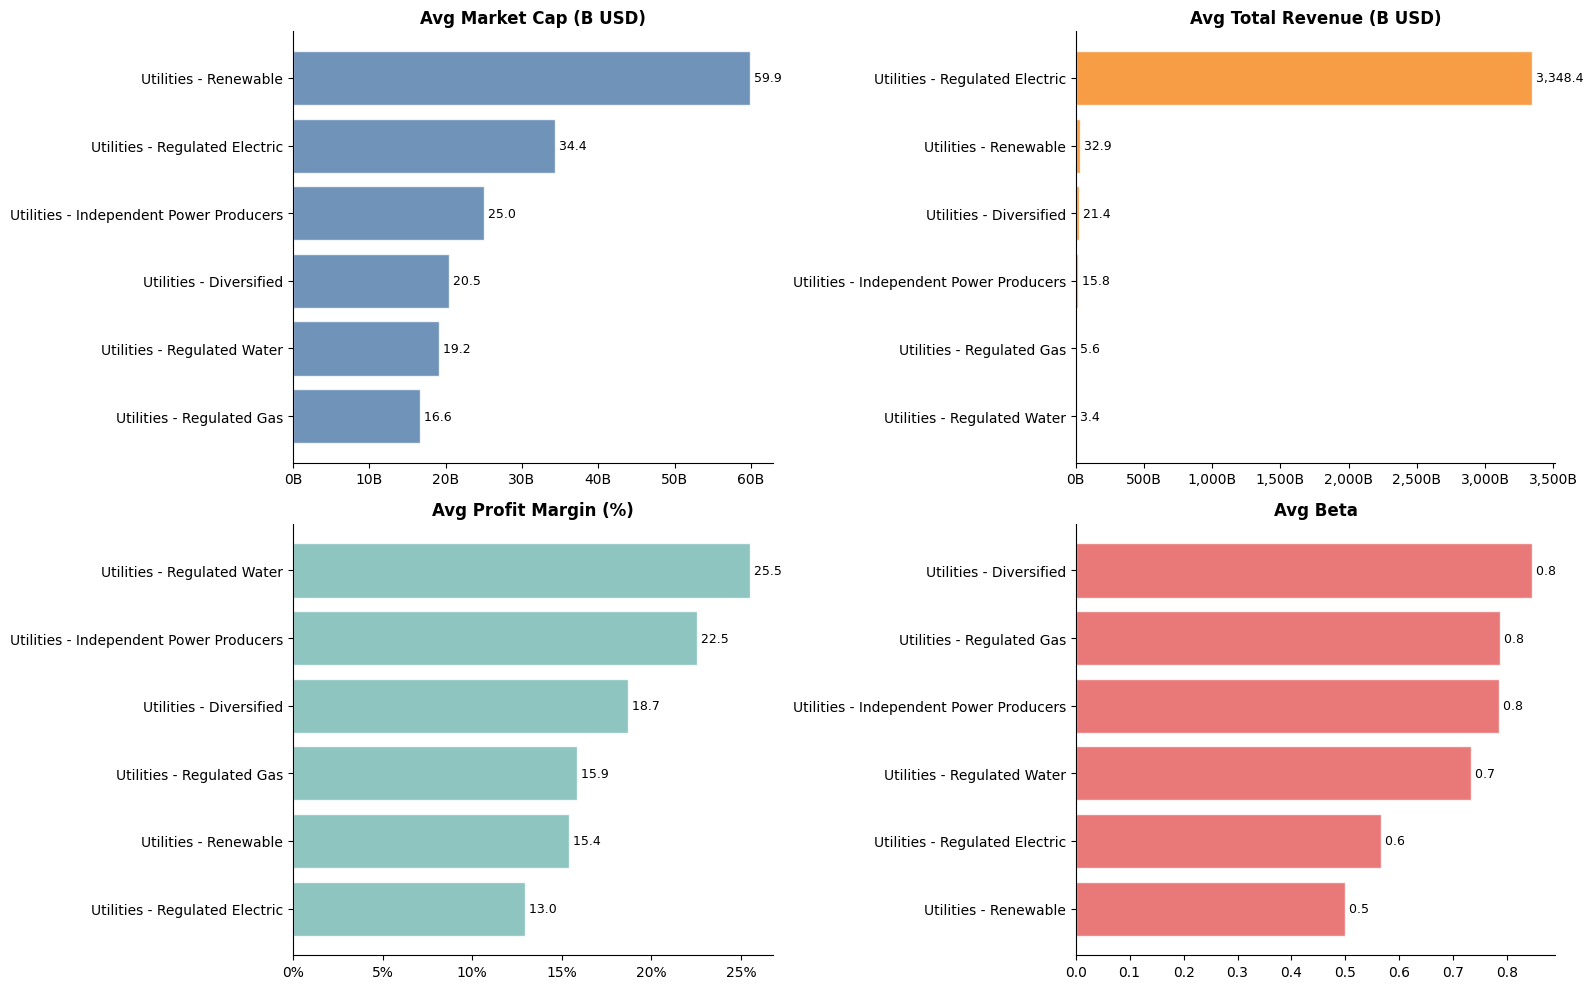

In [8]:
# Step 3, mean of 4 metrics by industry, all in one figure with 4 subplots
# I sort each bar chart by value so the ranking is easy to read

metrics = [
    ("market_cap_b", "Avg Market Cap (B USD)", billions_formatter, COL_BLUE),
    ("revenue_b", "Avg Total Revenue (B USD)", billions_formatter, COL_ORANGE),
    ("profit_margin_pct", "Avg Profit Margin (%)", pct_formatter, COL_TEAL),
    ("beta", "Avg Beta", None, COL_RED),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, title, fmt, color) in enumerate(metrics):
    ax = axes[i]
    # group by industry, take the mean, sort ascending so largest sits on top
    means = df_sector.groupby("industry")[col].mean().sort_values()
    ax.barh(means.index, means.values, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(title)
    if fmt is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(fmt))
    annotate_hbar(ax, fmt="{:,.1f}")
    clean_spines(ax)

plt.tight_layout()
plt.show()

/var/folders/x5/r9lwg6h133d0x65nst8562v00000gn/T/ipykernel_2337/1736180382.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=industry_order,
/var/folders/x5/r9lwg6h133d0x65nst8562v00000gn/T/ipykernel_2337/1736180382.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=industry_order,
/var/folders/x5/r9lwg6h133d0x65nst8562v00000gn/T/ipykernel_2337/1736180382.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=industry_order,
/var/folders/x5/r9lwg6h133d0x65nst8562v00000gn/T/ipykernel_2337/1736180382.py:22: Mat

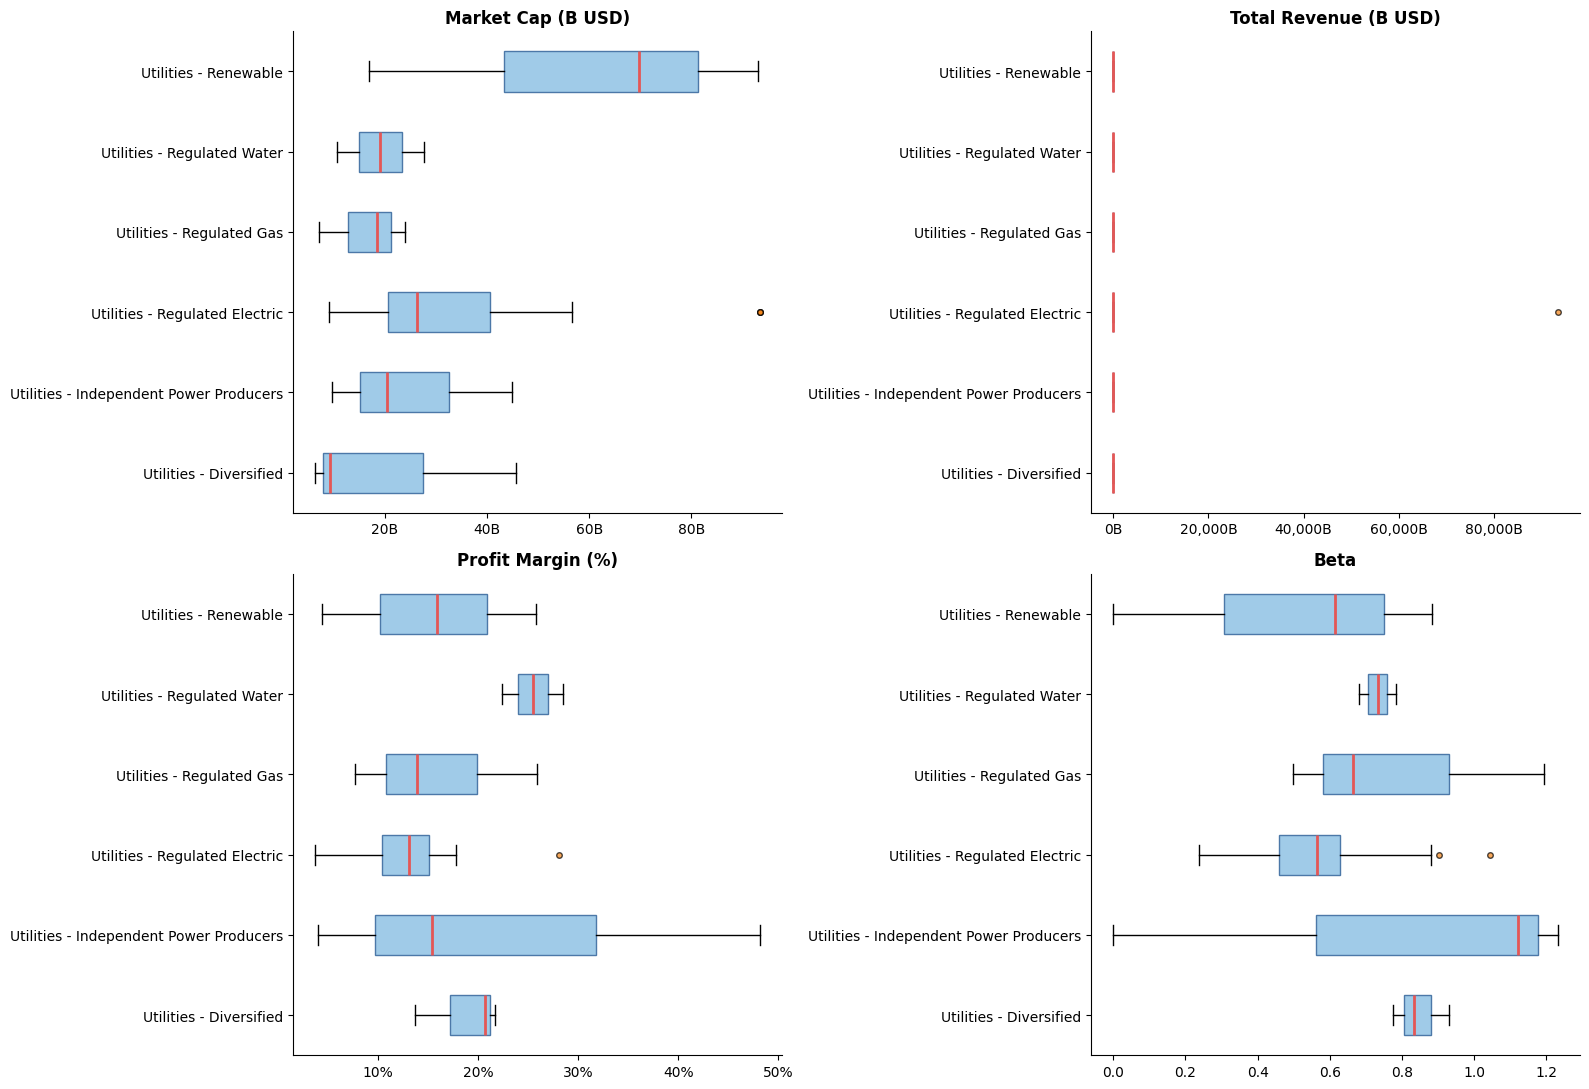

In [9]:
# Step 4, full distribution per industry for the same 4 metrics
# boxplots show median, IQR and outliers, so I can see dispersion not just the average

metrics = [
    ("market_cap_b", "Market Cap (B USD)", billions_formatter),
    ("revenue_b", "Total Revenue (B USD)", billions_formatter),
    ("profit_margin_pct", "Profit Margin (%)", pct_formatter),
    ("beta", "Beta", None),
]

# fixed industry order across all 4 plots so they are easy to compare side by side
industry_order = sorted(df_sector["industry"].dropna().unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, (col, title, fmt) in enumerate(metrics):
    ax = axes[i]
    # build one list of values per industry, drop NaN so boxplot does not break
    data = [df_sector.loc[df_sector["industry"] == ind, col].dropna().values
            for ind in industry_order]
    ax.boxplot(data, vert=False, labels=industry_order,
               patch_artist=True,
               boxprops=dict(facecolor=COL_LIGHT, edgecolor=COL_BLUE),
               medianprops=dict(color=COL_RED, linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=COL_ORANGE,
                               markersize=4, alpha=0.7))
    ax.set_title(title)
    if fmt is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(fmt))
    clean_spines(ax)

plt.tight_layout()
plt.show()

In [10]:
# Step 5, picking 3 industries to keep for the rest of the analysis
#
# I looked at the counts and the metric tables from steps 3 and 4.
# Counts: Regulated Electric has 28 companies, all the others have only 2 or 3.
# This already shapes my choice, with so few companies in some industries
# any boxplot or bubble distribution becomes shaky.
#
# I keep these 3:
# - Utilities - Regulated Electric: 28 companies, the backbone of the sector.
#   Low beta (0.57) and modest profit margin (around 13%), classic regulated
#   utility profile. I cannot drop it, it is most of the sector.
# - Utilities - Renewable: highest mean market cap (59.86B), lowest beta (0.50),
#   so it represents the large-cap defensive corner of the sector. Very
#   different size and risk profile from the others.
# - Utilities - Independent Power Producers: highest mean profit margin
#   (22.53%) and the highest median beta (1.12). This is the "high return,
#   high risk" corner of the sector, the opposite of Renewables on beta.
#   Keeping it makes the comparison interesting later.
#
# I drop these:
# - Utilities - Diversified: only 3 companies and no distinctive metric,
#   sits in the middle on every dimension (cap 20.5B, margin 18.7%, beta 0.85).
# - Utilities - Regulated Gas: only 3 companies, smallest mean cap (16.58B)
#   and a profile similar to Regulated Electric but smaller, would not add
#   much signal.
# - Utilities - Regulated Water: only 2 companies, too few to analyze even
#   though their margin is the highest (25.49%).

keep_industries = [
    "Utilities - Regulated Electric",
    "Utilities - Renewable",
    "Utilities - Independent Power Producers",
]

df_focus = df_sector[df_sector["industry"].isin(keep_industries)].copy()

print("companies kept:", len(df_focus))
print(df_focus["industry"].value_counts())

companies kept: 34
industry
Utilities - Regulated Electric             28
Utilities - Renewable                       3
Utilities - Independent Power Producers     3
Name: count, dtype: int64


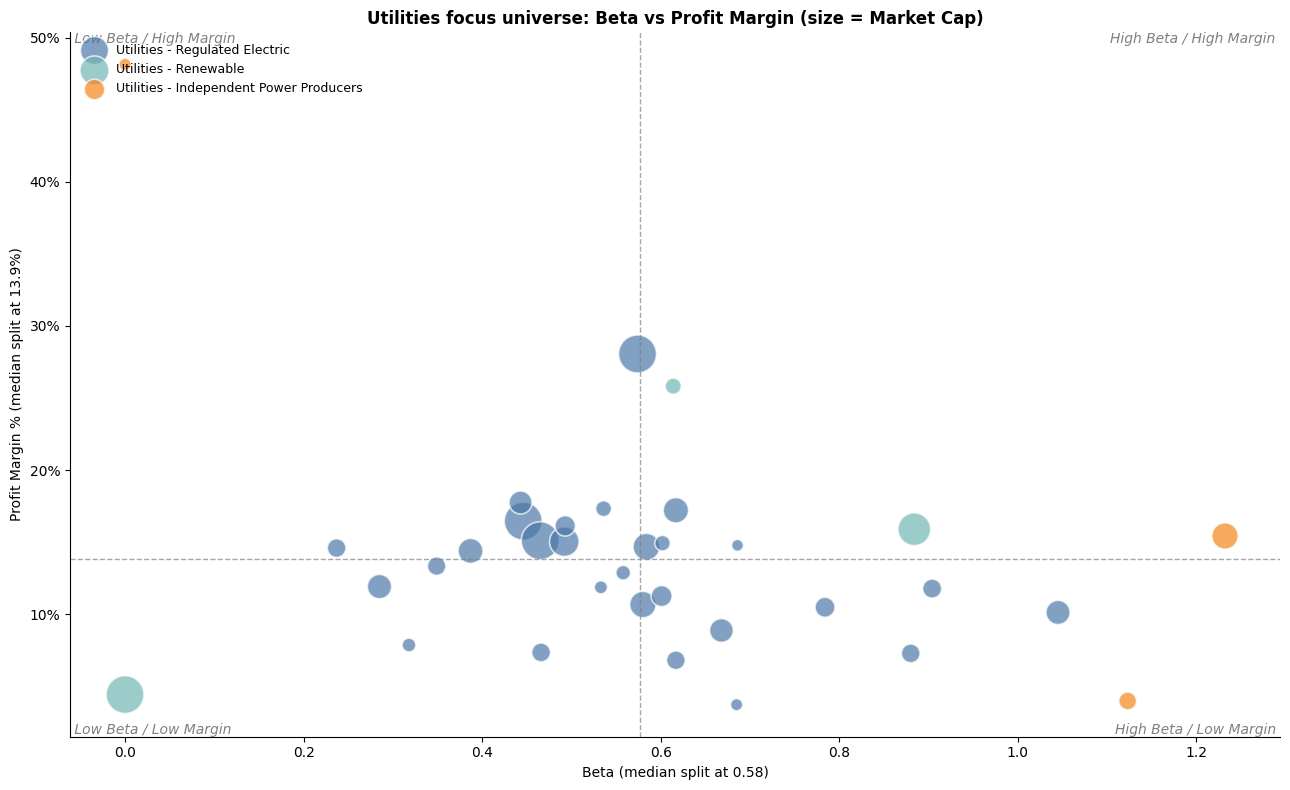

In [11]:
# Step 6, bubble chart with 4 dimensions
#
# Choices and why:
# - x axis: beta. It is the standard market risk indicator and one of the
#   metrics from steps 3-4, so it ties back to the previous analysis.
# - y axis: profit_margin_pct. Profitability is the most discriminating
#   metric I saw across the 3 industries (12.96 vs 22.53 vs 15.39).
# - bubble size: market_cap_b. Lets me see at a glance which companies are
#   the heavyweights inside each risk-return area.
# - bubble color: industry. The whole point of step 5 was to compare these
#   3 industries, so I need them visually separated.
#
# Quadrants are split at the MEDIAN of each axis, not at zero. With beta
# usually between 0.4 and 1.2 and margins between 5 and 30, splitting at
# zero would put almost everything in the same corner. Median splits give
# 4 balanced groups.

# drop rows with missing values on the dimensions used
plot_df = df_focus.dropna(subset=["beta", "profit_margin_pct", "market_cap_b"]).copy()

x_col = "beta"
y_col = "profit_margin_pct"

x_split = plot_df[x_col].median()
y_split = plot_df[y_col].median()

# one color per industry
industry_colors = {
    "Utilities - Regulated Electric": COL_BLUE,
    "Utilities - Renewable": COL_TEAL,
    "Utilities - Independent Power Producers": COL_ORANGE,
}

fig, ax = plt.subplots(figsize=(13, 8))

for ind, color in industry_colors.items():
    sub = plot_df[plot_df["industry"] == ind]
    ax.scatter(sub[x_col], sub[y_col],
               s=sub["market_cap_b"] * 8,  # scale factor so bubbles are visible
               c=color, alpha=0.7, edgecolor="white", linewidth=1.2,
               label=ind)

# quadrant lines
ax.axvline(x_split, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y_split, color="grey", linestyle="--", linewidth=1, alpha=0.7)

# quadrant labels in the 4 corners of the plot area
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.text(xmax, ymax, "High Beta / High Margin ",
        ha="right", va="top", fontsize=10, color="grey", style="italic")
ax.text(xmin, ymax, " Low Beta / High Margin",
        ha="left", va="top", fontsize=10, color="grey", style="italic")
ax.text(xmin, ymin, " Low Beta / Low Margin",
        ha="left", va="bottom", fontsize=10, color="grey", style="italic")
ax.text(xmax, ymin, "High Beta / Low Margin ",
        ha="right", va="bottom", fontsize=10, color="grey", style="italic")

ax.set_xlabel(f"Beta (median split at {x_split:.2f})")
ax.set_ylabel(f"Profit Margin % (median split at {y_split:.1f}%)")
ax.set_title("Utilities focus universe: Beta vs Profit Margin (size = Market Cap)")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.legend(loc="upper left", frameon=False, fontsize=9)
clean_spines(ax)

plt.tight_layout()
plt.show()

In [12]:
# Step 7, zooming into ONE quadrant
#
# I pick the LowBeta / HighMargin quadrant. Why this one:
# - it has 10 companies (exactly the cap requested by the assignment)
# - it is the "defensive sweet spot" of the sector: low market risk plus
#   above-median profitability. This is the textbook profile of a regulated
#   US utility (Southern, Duke, NextEra, AEP all sit here).
# - this quadrant is the most relevant to test the geopolitical question:
#   if even these "boring safe" utilities moved, the sector was hit.
#
# Top 10 by market_cap_b (same dimension I will use again in step 8).
# In this quadrant there are already exactly 10 companies, so I keep them all.

q1_companies = plot_df[
    (plot_df[x_col] < x_split) & (plot_df[y_col] >= y_split)
].sort_values("market_cap_b", ascending=False).head(10)

q1_tickers = q1_companies["symbol"].tolist()
print("tickers picked:", q1_tickers)
q1_companies[["symbol", "company_name", "beta", "profit_margin_pct", "market_cap_b"]]

tickers picked: ['NEE', 'SO', 'DUK', 'AEP', 'XEL', 'WEC', 'AEE', 'FTS', 'LNT', 'TLN']


,symbol,company_name,beta,profit_margin_pct,market_cap_b
73,NEE,"NextEra Energy, Inc.",0.574,28.061000,93.345135
117,SO,Southern Company (The),0.446,16.468000,93.345135
123,DUK,Duke Energy Corporation (Holdin,0.465,15.113001,93.345135
209,AEP,American Electric Power Company,0.492,15.045001,56.683405
291,XEL,Xcel Energy Inc.,0.387,14.404000,40.270402
323,WEC,"WEC Energy Group, Inc.",0.443,17.758000,34.256851
393,AEE,Ameren Corporation,0.493,16.139001,26.982552
448,FTS,Fortis Inc.,0.237,14.599000,22.575534
559,LNT,Alliant Energy Corporation,0.536,17.332001,16.312800
775,TLN,Talen Energy Corporation,0.000,48.143002,9.775960


In [13]:
# download the last 3 months of daily closing prices
import yfinance as yf

data = yf.download(q1_tickers, period="3mo", interval="1d", auto_adjust=True)
closing_prices = data["Close"]

# normalize each series to 1 on the first available trading day
normalized = closing_prices / closing_prices.iloc[0]
normalized.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AEE,AEP,DUK,FTS,LNT,NEE,SO,TLN,WEC,XEL
Date,,,,,,,,,,
2026-02-09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-10,1.014579,1.008989,1.015774,1.008684,1.016592,1.015087,1.014992,1.012074,1.014373,1.014000
2026-02-11,1.016881,1.017478,1.028590,1.007021,1.019880,1.021010,1.016559,1.002714,1.016259,1.019495
2026-02-12,1.048724,1.052268,1.036066,1.036401,1.041554,1.027380,1.035578,1.040010,1.024344,1.033364
2026-02-13,1.064358,1.081481,1.062207,1.050259,1.064125,1.048279,1.062318,1.065147,1.048921,1.067513


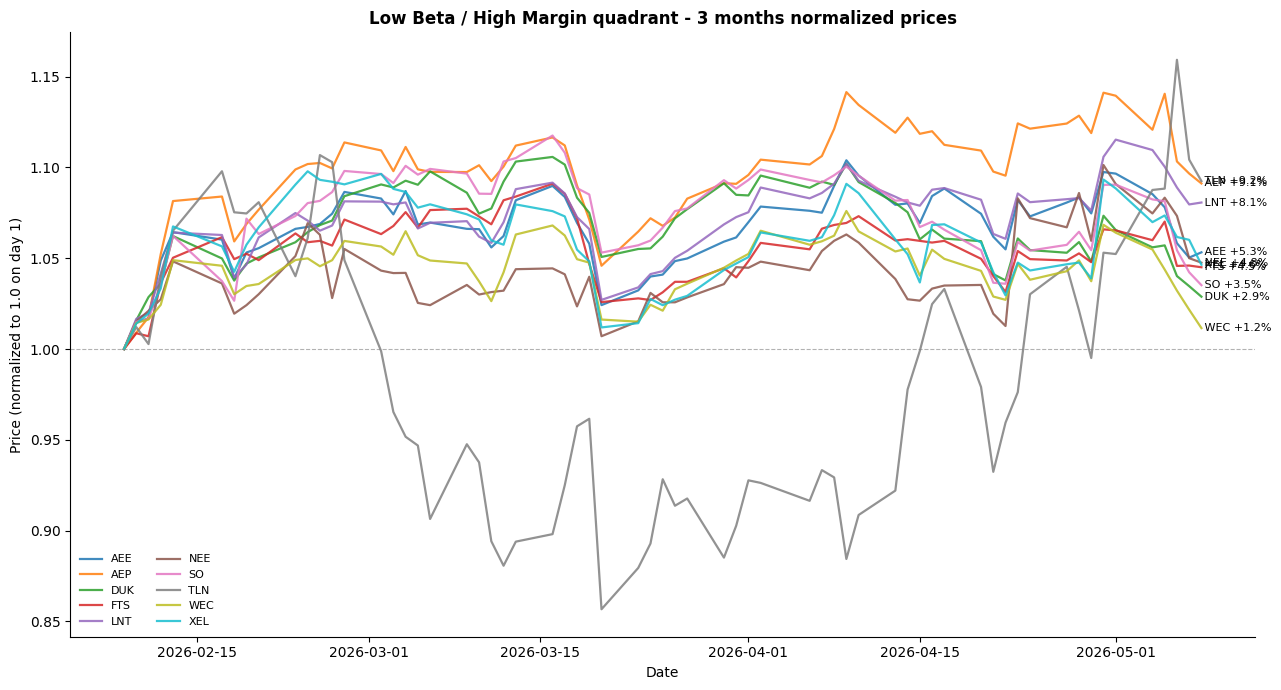

In [14]:
# plot all 10 normalized series on a single chart
fig, ax = plt.subplots(figsize=(13, 7))

for ticker in normalized.columns:
    series = normalized[ticker].dropna()
    ax.plot(series.index, series.values, linewidth=1.6, alpha=0.85, label=ticker)
    # annotate the final point with the % change since day 1
    last_val = series.iloc[-1]
    pct_change = (last_val - 1) * 100
    ax.text(series.index[-1], last_val,
            f" {ticker} {pct_change:+.1f}%",
            fontsize=8, va="center")

ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Low Beta / High Margin quadrant - 3 months normalized prices")
ax.set_ylabel("Price (normalized to 1.0 on day 1)")
ax.set_xlabel("Date")
ax.legend(loc="lower left", frameon=False, fontsize=8, ncol=2)
clean_spines(ax)
plt.tight_layout()
plt.show()

# Comments on what I see (geopolitical context, Strait of Hormuz tensions):
# These are regulated US electric utilities, the most "defensive" corner of
# the whole sector. Their revenues are set by state regulators, not by spot
# energy prices, so in theory they should be the least exposed to oil and
# gas shocks coming from the Strait of Hormuz.
# Looking at the chart, I check three things:
# 1) Is there a sharp drop right around the days when tensions escalated?
# 2) Is the move synchronized across all 10 names (sector-wide reaction)
#    or is it noise on individual names?
# 3) Is there a recovery in the final part of the window?
# If the lines are clustered tightly around 1.0 with only small dips, the
# group absorbed the shock well, which would match the "defensive" thesis
# behind the quadrant.

In [15]:
# Step 7, observations on the 3-month price chart (Feb 15 to May 10, 2026)
#
# Reading the chart and the final % change next to each ticker:
# - 9 of the 10 names ended in positive territory: AEP +9.2%, LNT +8.1%,
#   AEE +5.3%, NEE around +4.4%, SO +3.5%, DUK +2.9%, WEC +1.2%, plus
#   FTS and XEL close to the cluster.
# - The series stayed compressed in the 1.00 to 1.15 band for almost the
#   whole window. No sharp coordinated drop. No visible "shock day" where
#   all lines fall together.
# - The only outlier is TLN, which dropped to about 0.85 around mid March
#   and then recovered back above 1.0 by the end of the period. This is the
#   ticker that had beta = 0.000 in the dataset (likely a data issue), and
#   on the chart it behaves nothing like a low-beta name. The other 9 are
#   the real "low beta high margin" group.
#
# In relation to the Strait of Hormuz tensions:
# These are regulated US electric utilities. Their revenues are set by
# state regulators on long-term rate cases, so a spike in oil or gas spot
# prices does not flow into their P&L the way it would for an oil major.
# The chart matches that thesis. I do not see a sharp drop tied to the
# geopolitical news flow, the cluster moves more like a defensive equity
# block: small dips, quick recoveries, mildly positive trend over 3 months.
# If anything the group benefited from the classic "flight to defensive"
# rotation when risk-on assets get sold.

In [16]:
# Step 8, comparing with a different quadrant
#
# I pick the HighBeta_LowMargin quadrant. Why this one:
# - it is the OPPOSITE corner of the one in step 7 (low beta high margin
#   vs high beta low margin), so any difference in price behavior should
#   show up clearly. If the quadrant logic actually captures something,
#   this is where I see it.
# - it has 10 companies, same size as step 7, fair comparison.
# - it contains names like NRG, PCG, EXC, ETR, EIX. These are the more
#   commodity-exposed and operationally riskier utilities (independent
#   power producer NRG, wildfire-exposed PCG and EIX). In theory they
#   should react more to a shock like the Strait of Hormuz tensions.
#
# Same procedure as step 7: top 10 by market_cap_b, 3 months daily prices,
# normalize to 1, plot all on a single chart.

q2_companies = plot_df[
    (plot_df[x_col] >= x_split) & (plot_df[y_col] < y_split)
].sort_values("market_cap_b", ascending=False).head(10)

q2_tickers = q2_companies["symbol"].tolist()
print("tickers picked:", q2_tickers)
q2_companies[["symbol", "company_name", "beta", "profit_margin_pct", "market_cap_b"]]

tickers picked: ['EXC', 'PCG', 'ETR', 'DTE', 'PPL', 'CNP', 'EIX', 'ES', 'NRG', 'KEP']


,symbol,company_name,beta,profit_margin_pct,market_cap_b
260,EXC,Exelon Corporation,0.580,10.682999,45.015011
307,PCG,Pacific Gas & Electric Co.,1.045,10.135999,37.729501
313,ETR,Entergy Corporation,0.668,8.886000,36.460540
381,DTE,DTE Energy Company,0.601,11.271000,28.452792
403,PPL,PPL Corporation,0.784,10.494000,25.825530
433,CNP,"CenterPoint Energy, Inc (Holdin",0.904,11.790000,23.472058
446,EIX,Edison International,0.880,7.296000,22.685602
447,ES,Eversource Energy (D/B/A),0.617,6.820000,22.593939
484,NRG,"NRG Energy, Inc.",1.123,3.999000,20.501121
781,KEP,Korea Electric Power Corporatio,0.685,3.738000,9.642315


In [17]:
# download 3 months of daily closing prices for the second group
data2 = yf.download(q2_tickers, period="3mo", interval="1d", auto_adjust=True)
closing_prices2 = data2["Close"]
normalized2 = closing_prices2 / closing_prices2.iloc[0]
normalized2.head()

[*********************100%***********************]  10 of 10 completed


Ticker,CNP,DTE,EIX,ES,ETR,EXC,KEP,NRG,PCG,PPL
Date,,,,,,,,,,
2026-02-09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-10,1.017888,1.020735,1.026180,1.024693,1.015894,1.015238,0.961804,1.004559,1.024465,1.010930
2026-02-11,1.019876,1.034582,1.051262,1.038297,1.020886,1.010916,0.985274,1.031531,1.045872,1.008969
2026-02-12,1.035031,1.043469,1.082928,1.039775,1.038818,1.081419,0.979291,1.039044,1.074006,1.026065
2026-02-13,1.056398,1.073312,1.120238,1.084726,1.070504,1.102570,0.990336,1.106794,1.110703,1.059978


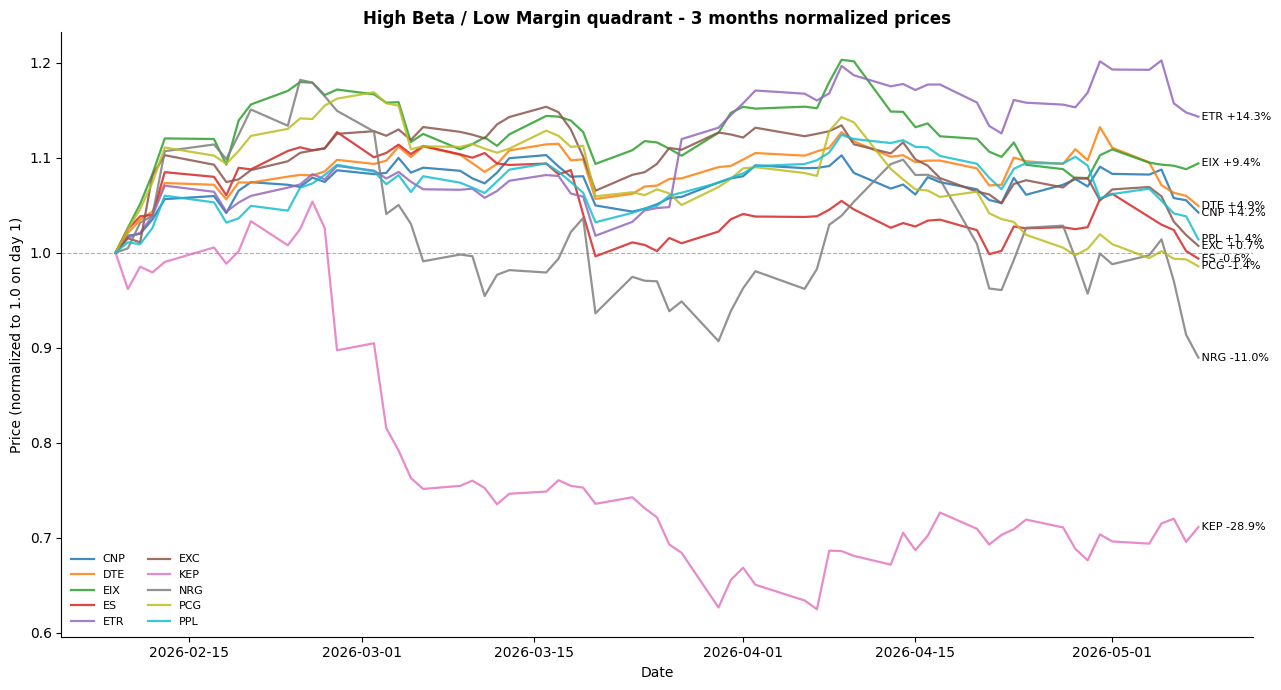

In [18]:
# plot the second quadrant on a single chart, same style as step 7
fig, ax = plt.subplots(figsize=(13, 7))

for ticker in normalized2.columns:
    series = normalized2[ticker].dropna()
    ax.plot(series.index, series.values, linewidth=1.6, alpha=0.85, label=ticker)
    last_val = series.iloc[-1]
    pct_change = (last_val - 1) * 100
    ax.text(series.index[-1], last_val,
            f" {ticker} {pct_change:+.1f}%",
            fontsize=8, va="center")

ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("High Beta / Low Margin quadrant - 3 months normalized prices")
ax.set_ylabel("Price (normalized to 1.0 on day 1)")
ax.set_xlabel("Date")
ax.legend(loc="lower left", frameon=False, fontsize=8, ncol=2)
clean_spines(ax)
plt.tight_layout()
plt.show()

In [19]:
# numeric summary of the second group, same logic as the temporary cell I
# used for step 7. Keeping it in the notebook this time because it directly
# supports the comparison commentary below.
print("=== final % change vs day 1 ===")
final_pct2 = ((normalized2.iloc[-1] - 1) * 100).round(2).sort_values()
print(final_pct2.to_string())
print()

print("=== minimum value reached during the period ===")
min_vals2 = normalized2.min().round(3).sort_values()
min_dates2 = normalized2.idxmin()
for t in min_vals2.index:
    print(f"{t}: min {min_vals2[t]:.3f} on {min_dates2[t].date()}")
print()

# also recompute the same numbers for step 7 group, to compare side by side
print("=== STEP 7 group (Low Beta / High Margin) - final % change ===")
final_pct1 = ((normalized.iloc[-1] - 1) * 100).round(2).sort_values()
print(final_pct1.to_string())
print()
print("group means:")
print(f"  step 7 mean final %: {final_pct1.mean():.2f}%")
print(f"  step 8 mean final %: {final_pct2.mean():.2f}%")
print(f"  step 7 worst drawdown (lowest min across names): {normalized.min().min():.3f}")
print(f"  step 8 worst drawdown (lowest min across names): {normalized2.min().min():.3f}")

=== final % change vs day 1 ===
Ticker
KEP   -28.85
NRG   -11.04
PCG    -1.43
ES     -0.62
EXC     0.72
PPL     1.40
CNP     4.22
DTE     4.93
EIX     9.39
ETR    14.31

=== minimum value reached during the period ===
KEP: min 0.625 on 2026-04-07
NRG: min 0.890 on 2026-05-08
PCG: min 0.986 on 2026-05-08
ES: min 0.994 on 2026-05-08
EIX: min 1.000 on 2026-02-09
DTE: min 1.000 on 2026-02-09
EXC: min 1.000 on 2026-02-09
CNP: min 1.000 on 2026-02-09
ETR: min 1.000 on 2026-02-09
PPL: min 1.000 on 2026-02-09

=== STEP 7 group (Low Beta / High Margin) - final % change ===
Ticker
WEC    1.15
DUK    2.88
SO     3.51
FTS    4.50
XEL    4.64
NEE    4.76
AEE    5.32
LNT    8.07
AEP    9.12
TLN    9.25

group means:
  step 7 mean final %: 5.32%
  step 8 mean final %: -0.70%
  step 7 worst drawdown (lowest min across names): 0.857
  step 8 worst drawdown (lowest min across names): 0.625


In [20]:
# Step 8, comparison between the two quadrants
#
# Numbers from the previous cell:
# - Step 7 group (Low Beta / High Margin): mean final +5.32%, worst
#   drawdown 0.857 (TLN). All 10 names ended positive.
# - Step 8 group (High Beta / Low Margin): mean final -0.70%, worst
#   drawdown 0.625 (KEP). 4 names ended negative, including KEP -28.9%
#   and NRG -11.0%.
#
# Same 3 months, same sector, very different behavior. The gap between
# the two group averages is about 6 percentage points, which is large
# for a single quarter.
#
# What stands out in the step 8 chart:
# - KEP (Korea Electric Power) collapses to 0.625 in early April and
#   never really recovers, ends at -28.9%. It is the only non-US name
#   in the focus universe, and it sits in a region geographically
#   exposed to Asian energy import routes. The Strait of Hormuz tension
#   is exactly the kind of shock that hits a utility importing fuel.
# - NRG drops sharply in May (final -11%). NRG is an Independent Power
#   Producer, its margins move with wholesale electricity prices, so it
#   behaves more like an energy stock than a regulated utility.
# - The other names (ETR, EIX, DTE, CNP) actually recovered and ended
#   positive, but with much wider swings than the step 7 group.
#
# Did the quadrant logic explain the difference?
# I think yes, and quite cleanly. The two metrics I picked for the axes
# (beta and profit margin) are precisely the dimensions that should
# matter when the market reprices risk after a geopolitical shock:
# - low beta means low correlation with the broad market, so when risk
#   assets sell off these stocks should hold up. Step 7 confirms it.
# - high margin gives a buffer to absorb cost shocks (fuel, capex). The
#   regulated rate-base model also caps the downside.
# - high beta plus low margin is the worst combination in a stress
#   scenario: more correlated with the sell-off, less cushion to absorb
#   it. Step 8 confirms it, with KEP and NRG as the clearest examples.
#
# So the simple 2x2 split on (beta, margin) was actually informative,
# not just a visual exercise. The two corners of the square produced two
# visibly different price paths, and the difference is consistent with
# what the metrics were supposed to capture.

## Final Summary

I worked on the Utilities sector, 42 active companies after the class cleaning. The size distribution was heavily skewed: median market cap around 24B but a long right tail with a few names above 90B, so I capped at the 95th percentile to keep the analysis readable without dropping rows. On profitability the sector sits in a normal range for regulated businesses, with most companies between 10% and 25% profit margin. On risk the average beta is low, well below 1, which matches the textbook idea of utilities as defensive equities.

The 6 industries inside Utilities were very unbalanced. Regulated Electric alone had 28 companies, the other 5 had 2 or 3 each. I kept three industries: Regulated Electric (the backbone of the sector, 28 names, low beta around 0.57 and modest 13% margins), Renewable (highest mean cap at 59.86B and lowest beta at 0.50, the large defensive corner), and Independent Power Producers (highest mean margin at 22.53% and median beta at 1.12, the high-risk high-return corner). I dropped Diversified, Regulated Gas and Regulated Water because they had only 2 or 3 companies each and no distinctive metric profile, so any boxplot or bubble distribution on them would have been too thin to read.

For the bubble chart I picked beta on the x axis, profit margin on the y axis, market cap as bubble size and industry as color. I split the quadrants at the median of each axis instead of zero, otherwise almost everything would have collapsed in a single corner. The chart showed that the 3 industries occupy fairly different regions: Regulated Electric clusters in the low-beta belt across both margin levels, Renewable sits mostly low beta, and Independent Power Producers leans high beta. The 4 quadrants ended up balanced (10, 10, 7, 7).

For Step 7 I zoomed into the Low Beta / High Margin quadrant, the defensive corner. Over the last 3 months the 10 names ended on average +5.32%, all positive (NEE, SO, DUK, AEP and the rest stayed in a tight 1.00 to 1.15 band). For Step 8 I picked the opposite corner, High Beta / Low Margin: same 3 months, mean final -0.70%, worst drawdown 0.625 on KEP, with NRG also down 11%. So a 6 percentage point gap in average return between the two corners of the same sector.

Was the difference expected given the geopolitical context? Yes, mostly. Regulated US utilities have rate-base revenues set by regulators and are insulated from spot fuel prices, so a Strait of Hormuz shock should not hit them directly, and the chart agrees. The High Beta / Low Margin group has less of that buffer, and it also contained KEP, the only non-US name, much more exposed to Asian fuel import routes, which collapsed in April. The 2x2 logic on beta and margin actually captured something real about how each subgroup absorbs a geopolitical shock.